<a href="https://colab.research.google.com/github/rpark3/ECON3916-Statistical-Machine-Learning/blob/main/Assignment%205/Assignment_5_The_Sovereign_Risk_Engine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install wbgapi scikit-learn statsmodels matplotlib seaborn numpy pandas -q

In [ ]:
import wbgapi as wb
import pandas as pd
import numpy as np
from sklearn.linear_model import (LinearRegression, RidgeCV, LassoCV, LogisticRegression)
from sklearn.linear_model import lasso_path
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (confusion_matrix, classification_report, roc_curve, roc_auc_score,precision_recall_curve,f1_score, precision_score, recall_score)
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
INDICATORS = {
    # Growth outcome (our y)
    'NY.GDP.PCAP.KD.ZG': 'gdp_growth_pc',

    # Trade & Openness
    'NE.TRD.GNFS.ZS':    'trade_pct_gdp',
    'BX.KLT.DINV.WD.GD.ZS': 'fdi_inflows_pct_gdp',
    'TM.TAX.MRCH.SM.AR.ZS': 'tariff_rate_avg',
    'BX.GSR.ROYL.CD':    'royalties_receipts',

    # Macroeconomics
    'FP.CPI.TOTL.ZG':    'inflation_cpi',
    'GC.DOD.TOTL.GD.ZS': 'govt_debt_pct_gdp',
    'GC.XPN.TOTL.GD.ZS': 'govt_expenditure_pct_gdp',
    'BN.CAB.XOKA.GD.ZS': 'current_account_pct_gdp',
    'FR.INR.RINR':       'real_interest_rate',
    'PA.NUS.FCRF':       'exchange_rate_official',

    # Education & Human Capital
    'SE.SEC.ENRR':       'secondary_enrollment_gross',
    'SE.TER.ENRR':       'tertiary_enrollment_gross',
    'SE.ADT.LITR.ZS':    'adult_literacy_rate',
    'SE.XPD.TOTL.GD.ZS': 'education_expenditure_pct_gdp',
    'SL.UEM.TOTL.ZS':    'unemployment_rate',

    # Infrastructure & Technology
    'IT.NET.USER.ZS':    'internet_users_pct',
    'IT.CEL.SETS.P2':    'mobile_subscriptions_per100',
    'EG.ELC.ACCS.ZS':    'electricity_access_pct',
    'IS.ROD.PAVE.ZS':    'paved_roads_pct',

    # Health & Demographics
    'SP.DYN.LE00.IN':    'life_expectancy',
    'SH.DYN.MORT':       'infant_mortality_per1000',
    'SP.POP.GROW':       'population_growth',
    'SP.URB.TOTL.IN.ZS': 'urbanization_pct',
    'SH.XPD.CHEX.GD.ZS': 'health_expenditure_pct_gdp',

    # Finance & Banking
    'FS.AST.DOMS.GD.ZS': 'domestic_credit_pct_gdp',
    'CM.MKT.LCAP.GD.ZS': 'market_cap_pct_gdp',
    'FB.ATM.TOTL.P5':    'atms_per100k',
    'FD.AST.PRVT.GD.ZS': 'private_credit_pct_gdp',

    # Natural Resources
    'NY.GDP.TOTL.RT.ZS': 'natural_resource_rents_pct_gdp',
    'EG.FEC.RNEW.ZS':    'renewable_energy_pct',
    'EN.ATM.CO2E.PC':    'co2_emissions_per_capita',

    # Agriculture
    'NV.AGR.TOTL.ZS':    'agriculture_pct_gdp',
    'AG.LND.ARBL.ZS':    'arable_land_pct',

    # Governance (World Bank Governance Indicators)
    'IQ.CPA.TRAD.XQ':    'trade_cpia',
    'IQ.CPA.FINS.XQ':    'financial_management_cpia',
    'IQ.CPA.PROP.XQ':    'property_rights_cpia',
}

OUTCOME_VAR = 'gdp_growth_pc'
indicator_list = list(INDICATORS.keys())

print(f"Downloading {len(indicator_list)} indicators for all countries, 2013–2019...")
print("(This may take 30–60 seconds — API call to World Bank)")

# Download 7 years of data (2013–2019, pre-COVID) and average
# wb.data.DataFrame returns a DataFrame indexed by (economy, time) or (economy)
try:
    raw_data = wb.data.DataFrame(
        indicator_list,
        time=range(2013, 2020),  # 2013–2019
        skipBlanks=True,
        labels=False
    )
    raw_data.columns = [INDICATORS[c] if c in INDICATORS else c for c in raw_data.columns]
    print(f"Raw data shape: {raw_data.shape}")
    print("Download successful ✓")
except Exception as e:
    print(f"API error: {e}")
    print("Loading fallback data from CSV...")
    # Fallback: load pre-downloaded CSV
    # raw_data = pd.read_csv('data/fallback_wdi_topic16.csv', index_col=[0, 1])

(This may take 30–60 seconds — API call to World Bank)
Raw data shape: (7211, 7)
Download successful ✓


In [ ]:
if isinstance(raw_data.index, pd.MultiIndex):
    # Take the mean across columns (years) for each (economy, series) pair
    averaged_by_series = raw_data.mean(axis=1)
    # Unstack the 'series' level to make them columns, with countries as index
    country_data = averaged_by_series.unstack(level='series')
    # Rename indicator codes to human-readable names
    country_data = country_data.rename(columns=INDICATORS)
else:
    country_data = raw_data.copy()

# Drop countries with too many missing values (keep countries with >= 60% non-missing)
threshold = 0.40
country_data = country_data.dropna(thresh=int(threshold * country_data.shape[1]))

# Drop indicators with too many missing values across countries
country_data = country_data.dropna(axis=1, thresh=int(threshold * len(country_data)))

# Final fill: impute remaining missing values with the cross-country median
# (Standard practice in cross-country empirics — removes selection bias from listwise deletion)
country_data = country_data.fillna(country_data.median())

print(f"Final dataset: {len(country_data)} countries \u00d7 {country_data.shape[1]} indicators")
print(f"\nSample countries: {list(country_data.index[:5])}")
print(f"\nIndicators retained: {list(country_data.columns)}")
print(f"\nGDP growth summary:")
print(country_data[OUTCOME_VAR].describe().round(2))

Final dataset: 253 countries × 33 indicators

Sample countries: ['ABW', 'AFE', 'AFG', 'AFW', 'AGO']

Indicators retained: ['arable_land_pct', 'current_account_pct_gdp', 'royalties_receipts', 'fdi_inflows_pct_gdp', 'market_cap_pct_gdp', 'electricity_access_pct', 'renewable_energy_pct', 'atms_per100k', 'private_credit_pct_gdp', 'inflation_cpi', 'real_interest_rate', 'govt_expenditure_pct_gdp', 'financial_management_cpia', 'property_rights_cpia', 'trade_cpia', 'mobile_subscriptions_per100', 'internet_users_pct', 'trade_pct_gdp', 'agriculture_pct_gdp', 'gdp_growth_pc', 'natural_resource_rents_pct_gdp', 'exchange_rate_official', 'adult_literacy_rate', 'secondary_enrollment_gross', 'tertiary_enrollment_gross', 'education_expenditure_pct_gdp', 'infant_mortality_per1000', 'health_expenditure_pct_gdp', 'unemployment_rate', 'life_expectancy', 'population_growth', 'urbanization_pct', 'tariff_rate_avg']

GDP growth summary:
count    253.00
mean       1.77
std        2.54
min      -12.55
25%       

In [ ]:
# ============================================================
# PART 1C: Train-Test Split & OLS Baseline
# ============================================================
# We split countries (not time periods) into train/test sets.
# This tests whether our model generalizes across countries —
# the realistic use case for an IMF forecaster.

# Separate outcome (y) from predictors (X)
feature_cols = [c for c in country_data.columns if c != OUTCOME_VAR]

X = country_data[feature_cols].values
y = country_data[OUTCOME_VAR].values
feature_names = feature_cols

# 70/30 train-test split (stratified not needed for regression)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)

print(f"Training countries: {X_train.shape[0]}")
print(f"Test countries: {X_test.shape[0]}")
print(f"Number of predictors: {X_train.shape[1]}")
print(f"Predictor-to-observation ratio (train): p/n = {X_train.shape[1]}/{X_train.shape[0]} = {X_train.shape[1]/X_train.shape[0]:.2f}")
print()
print("If p/n > 0.5, OLS is at serious risk of overfitting.")

# Standardize features (critical for Ridge and Lasso — do it manually here to inspect later)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # fit on train only!
X_test_scaled  = scaler.transform(X_test)         # apply same transform to test

print("\nFeatures standardized (zero mean, unit variance) ✓")

Training countries: 177
Test countries: 76
Number of predictors: 32
Predictor-to-observation ratio (train): p/n = 32/177 = 0.18

If p/n > 0.5, OLS is at serious risk of overfitting.

Features standardized (zero mean, unit variance) ✓


In [ ]:
ols_model = LinearRegression()
ols_model.fit(X_train_scaled, y_train)

# Training performance
y_train_pred_ols = ols_model.predict(X_train_scaled)
ols_train_r2  = r2_score(y_train, y_train_pred_ols)
ols_train_mse = mean_squared_error(y_train, y_train_pred_ols)

# Test performance
y_test_pred_ols = ols_model.predict(X_test_scaled)
ols_test_r2  = r2_score(y_test, y_test_pred_ols)
ols_test_mse = mean_squared_error(y_test, y_test_pred_ols)

print("=" * 45)
print("OLS BASELINE RESULTS")
print("=" * 45)
print(f"Training R²:  {ols_train_r2:.3f}")
print(f"Test R²:      {ols_test_r2:.3f}")
print(f"")
print(f"Training MSE: {ols_train_mse:.3f}")
print(f"Test MSE:     {ols_test_mse:.3f}")
print(f"")
print(f"Gap (Train R² - Test R²): {ols_train_r2 - ols_test_r2:.3f}")
print("=" * 45)
print()
print("Interpretation:")
print(f"  OLS fits the training data {ols_train_r2:.0%} — but only explains")
print(f"  {max(ols_test_r2, 0):.0%} of test variance. This is overfitting.")

OLS BASELINE RESULTS
Training R²:  0.489
Test R²:      0.098

Training MSE: 2.657
Test MSE:     8.394

Gap (Train R² - Test R²): 0.391

Interpretation:
  OLS fits the training data 49% — but only explains
  10% of test variance. This is overfitting.


Written response (2–3 sentences): Connect the p/n ratio to the R² gap. Why does a high p/n ratio cause OLS to overfit? Use the terms bias, variance, and degrees of freedom in your explanation.

1. A high p/n ratio means that OLS is trying to estimate to many parameters relative to the amount of training data. This results in a higher training R^2 compared to test R^2. The model produces low bias but high variance.


In [ ]:
lambda_grid = np.logspace(-2, 3, 50)

# TODO: Create a RidgeCV with 5-fold CV and the lambda_grid above
# Hint: RidgeCV(alphas=..., cv=5)
ridge_cv = RidgeCV(alphas=lambda_grid, cv=5)  # ← complete this line

# TODO: Fit ridge_cv on the scaled training data
ridge_cv.fit(X_train_scaled, y_train)  # ← complete this line

# Evaluate on test set
y_test_pred_ridge = ridge_cv.predict(X_test_scaled)
ridge_test_r2  = r2_score(y_test, y_test_pred_ridge)
ridge_test_rmse = mean_squared_error(y_test, y_test_pred_ridge)

print("=" * 45)
print("RIDGE REGRESSION RESULTS")
print("=" * 45)
print(f"Optimal λ* (CV-selected): {ridge_cv.alpha_:.4f}")
print(f"Non-zero coefficients:    {np.sum(ridge_cv.coef_ != 0)} of {X_train.shape[1]}")
print(f"Test R²:                  {ridge_test_r2:.3f}")
print(f"Test RMSE:                 {ridge_test_rmse:.3f}")
print()
print(f"vs. OLS: Test R² = {ols_test_r2:.3f}, Test MSE = {ols_test_mse:.3f}")

RIDGE REGRESSION RESULTS
Optimal λ* (CV-selected): 75.4312
Non-zero coefficients:    32 of 32
Test R²:                  0.239
Test RMSE:                 7.080

vs. OLS: Test R² = 0.098, Test MSE = 8.394


In [ ]:
def fit_lasso_cv(X_train, y_train, X_test, y_test, cv=5):
    """
    Fit LassoCV to select optimal regularization parameter and evaluate on test set.

    Parameters
    ----------
    X_train : np.ndarray, shape (n_train, p)
        Standardized training features
    y_train : np.ndarray, shape (n_train,)
        Training outcome (GDP growth)
    X_test : np.ndarray, shape (n_test, p)
        Standardized test features (same scaler as train)
    y_test : np.ndarray, shape (n_test,)
        Test outcome
    cv : int
        Number of cross-validation folds

    Returns
    -------
    lasso_model : LassoCV
        Fitted LassoCV model with optimal alpha stored in .alpha_
    test_r2 : float
        R² on held-out test set
    test_mse : float
        Mean squared error on held-out test set
    """
    # TODO: Create a LassoCV with cv folds and max_iter=10_000
    # (max_iter needs to be high for coordinate descent to converge)
    lasso_model = LassoCV(cv=cv, max_iter=10_000, random_state=42)  # ← your code here

    # TODO: Fit the model on training data
    lasso_model.fit(X_train, y_train)  # ← your code here

    # Predict on test set
    y_pred = lasso_model.predict(X_test)

    # TODO: Compute test R² and test MSE
    test_r2  = r2_score(y_test, y_pred)  # ← your code here
    test_rmse = mean_squared_error(y_test, y_pred)  # ← your code here

    return lasso_model, test_r2, test_rmse


# Call the function
lasso_cv_model, lasso_test_r2, lasso_test_rmse = fit_lasso_cv(
    X_train_scaled, y_train, X_test_scaled, y_test, cv=5
)

n_nonzero = np.sum(lasso_cv_model.coef_ != 0)

print("=" * 45)
print("LASSO REGRESSION RESULTS")
print("=" * 45)
print(f"Optimal λ* (CV-selected): {lasso_cv_model.alpha_:.4f}")
print(f"Non-zero coefficients:    {n_nonzero} of {X_train.shape[1]}")
print(f"Test R²:                  {lasso_test_r2:.3f}")
print(f"Test RMSE:                 {lasso_test_rmse:.3f}")
print()
print("Selected predictors (non-zero Lasso coefficients):")
selected_features = [
    (feature_names[i], lasso_cv_model.coef_[i])
    for i in range(len(feature_names))
    if lasso_cv_model.coef_[i] != 0
]
for name, coef in sorted(selected_features, key=lambda x: abs(x[1]), reverse=True):
    print(f"  {name:<40} coef = {coef:+.4f}")

LASSO REGRESSION RESULTS
Optimal λ* (CV-selected): 0.1226
Non-zero coefficients:    15 of 32
Test R²:                  0.267
Test RMSE:                 6.822

Selected predictors (non-zero Lasso coefficients):
  population_growth                        coef = -0.5369
  urbanization_pct                         coef = -0.5206
  inflation_cpi                            coef = -0.3910
  exchange_rate_official                   coef = +0.3351
  unemployment_rate                        coef = -0.2512
  arable_land_pct                          coef = +0.2086
  renewable_energy_pct                     coef = +0.2032
  property_rights_cpia                     coef = +0.1853
  secondary_enrollment_gross               coef = +0.1845
  natural_resource_rents_pct_gdp           coef = -0.1215
  internet_users_pct                       coef = -0.1106
  trade_pct_gdp                            coef = +0.1036
  financial_management_cpia                coef = +0.0638
  electricity_access_pct            

In [ ]:
comparison = pd.DataFrame({
    'Method': ['OLS', 'Ridge (RidgeCV)', 'Lasso (LassoCV)'],
    'Lambda (α*)': [
        'N/A (no penalty)',
        f'{ridge_cv.alpha_:.4f}',
        f'{lasso_cv_model.alpha_:.4f}'
    ],
    'Non-zero Predictors': [
        X_train.shape[1],                        # OLS: all predictors non-zero
        X_train.shape[1],                        # Ridge: all predictors non-zero
        np.sum(lasso_cv_model.coef_ != 0)        # Lasso: only selected predictors
    ],
    'Training R²': [
        f'{r2_score(y_train, ols_model.predict(X_train_scaled)):.3f}',
        f'{r2_score(y_train, ridge_cv.predict(X_train_scaled)):.3f}',
        f'{r2_score(y_train, lasso_cv_model.predict(X_train_scaled)):.3f}'
    ],
    'Test R²': [
        f'{ols_test_r2:.3f}',
        f'{ridge_test_r2:.3f}',
        f'{lasso_test_r2:.3f}'
    ],
    'Test MSE': [
        f'{ols_test_mse:.3f}',
        f'{ridge_test_mse:.3f}',
        f'{lasso_test_mse:.3f}'
    ]
})

print(comparison.to_string(index=False))
print()
print("Key observations:")
print(f"  • OLS training R² >> test R²: evidence of overfitting (high variance)")
print(f"  • Ridge and Lasso reduce the train-test gap")
print(f"  • Lasso selects only {np.sum(lasso_cv_model.coef_ != 0)} of {X_train.shape[1]} predictors")
print(f"  • Interpretation: the other {X_train.shape[1] - np.sum(lasso_cv_model.coef_ != 0)} are predictively redundant,")
print(f"    not necessarily economically unimportant")

         Method      Lambda (α*)  Non-zero Predictors Training R² Test R² Test MSE
            OLS N/A (no penalty)                   32       0.489   0.098    8.394
Ridge (RidgeCV)          75.4312                   32       0.414   0.239    7.080
Lasso (LassoCV)           0.1226                   15       0.378   0.267    6.822

Key observations:
  • OLS training R² >> test R²: evidence of overfitting (high variance)
  • Ridge and Lasso reduce the train-test gap
  • Lasso selects only 15 of 32 predictors
  • Interpretation: the other 17 are predictively redundant,
    not necessarily economically unimportant


Written response (2–3 sentences): Which model would you recommend to the IMF Director for operational GDP growth forecasting? Justify using the bias-variance tradeoff: explain what Ridge and Lasso each sacrifice (in terms of bias) to gain (in terms of variance reduction).

1. I would recommend the Ridge/Lasso model to the IMF director. Ridge improves the stability by shrinking coefficients toward 0, and Lasso sets some coefficients to 0, resulting in higher bias but lower variance.

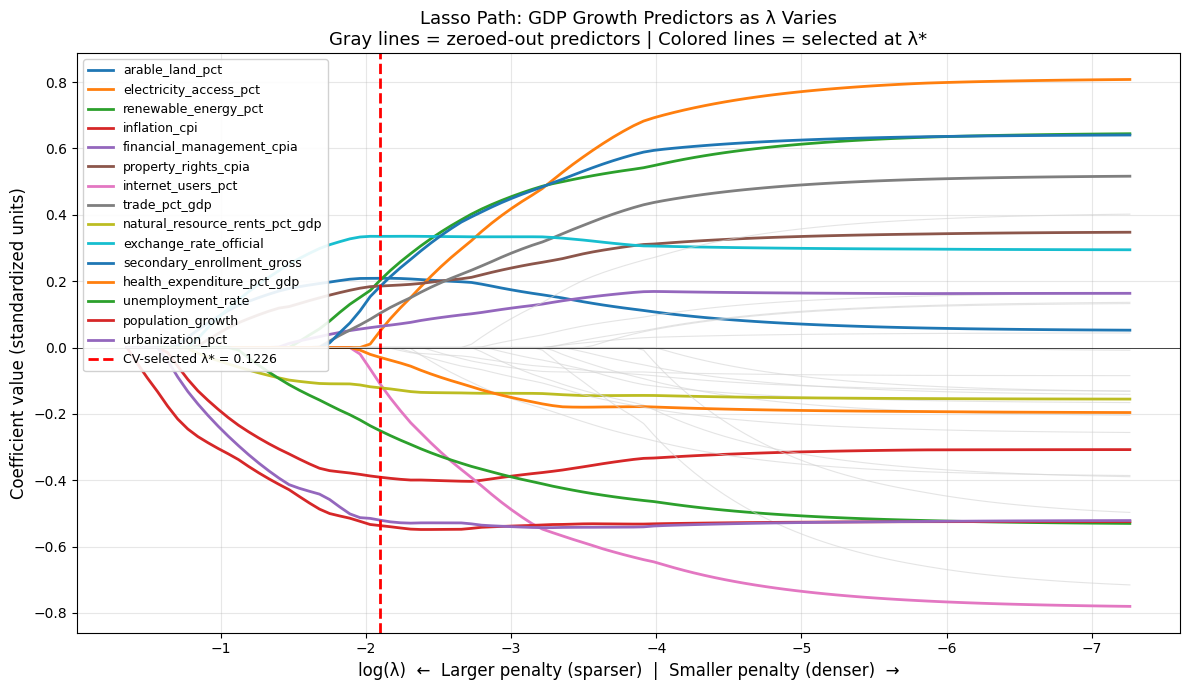

Lasso Path saved to lasso_path_gdp_growth.png


In [ ]:
alphas_path, coefs_path, _ = lasso_path(
    X_train_scaled, y_train,
    eps=1e-3,       # ratio of min to max alpha in the path
    n_alphas=100,   # number of points on the path
)
# coefs_path shape: (n_features, n_alphas)

# Mark our CV-selected lambda
optimal_alpha = lasso_cv_model.alpha_

# ── PLOT ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 7))

# Plot each predictor's coefficient path
# Only label the lines that are non-zero at optimal λ (to avoid clutter)
active_features_idx = np.where(lasso_cv_model.coef_ != 0)[0]

for i in range(len(feature_names)):
    if i in active_features_idx:
        ax.plot(np.log(alphas_path), coefs_path[i],
                linewidth=2, label=feature_names[i])
    else:
        ax.plot(np.log(alphas_path), coefs_path[i],
                linewidth=0.8, color='lightgray', alpha=0.6)

# Mark the CV-selected lambda
ax.axvline(np.log(optimal_alpha), color='red', linestyle='--', linewidth=2,
           label=f'CV-selected λ* = {optimal_alpha:.4f}')
ax.axhline(0, color='black', linewidth=0.5)

# Labels and formatting
ax.set_xlabel('log(λ)  ←  Larger penalty (sparser)  |  Smaller penalty (denser)  →',
               fontsize=12)
ax.set_ylabel('Coefficient value (standardized units)', fontsize=12)
ax.set_title(
    'Lasso Path: GDP Growth Predictors as λ Varies\n'
    'Gray lines = zeroed-out predictors | Colored lines = selected at λ*',
    fontsize=13
)
ax.legend(loc='upper left', fontsize=9, framealpha=0.9)
ax.invert_xaxis()  # Large lambda on left → small lambda on right (path goes left to right)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('lasso_path_gdp_growth.png', dpi=150, bbox_inches='tight')
plt.show()
print("Lasso Path saved to lasso_path_gdp_growth.png")

Written response (3–4 sentences): A World Bank colleague argues: “Lasso zeroed out life_expectancy, so health is irrelevant to economic growth.” Explain why this interpretation is wrong. Use the terms conditional predictive redundancy and correlation structure.

1. The world bank colleague's interpretation is wrong because Lasso dropping life_expectancy does not mean health is irrelevant to growth. It means that, conditional on the other predictors in the model, life expectancy did not add enough information. Lasso is detecting conditional predictive redundancy created by the correlation structure.

In [ ]:
lasso_selected_idx = np.where(lasso_cv_model.coef_ != 0)[0]
X_train_lpm = X_train_scaled[:, lasso_selected_idx]
X_test_lpm  = X_test_scaled[:,  lasso_selected_idx]


y_binary_train = (y_train < 0).astype(int)
y_binary_test  = (y_test  < 0).astype(int)


lpm_model = LinearRegression()
lpm_model.fit(X_train_lpm, y_binary_train)

lpm_preds = lpm_model.predict(X_test_lpm)

n_below_zero = (lpm_preds < 0).sum()
n_above_one  = (lpm_preds > 1).sum()

print(f"Out-of-bounds predictions:")
print(f"  Predicted probability < 0: {n_below_zero} ({n_below_zero/len(lpm_preds):.1%})")
print(f"  Predicted probability > 1: {n_above_one}  ({n_above_one/len(lpm_preds):.1%})")
print(f"\nMin: {lpm_preds.min():.4f}  Max: {lpm_preds.max():.4f}")

Out-of-bounds predictions:
  Predicted probability < 0: 14 (18.4%)
  Predicted probability > 1: 2  (2.6%)

Min: -0.2181  Max: 2.1091


Written response (2–3 sentences): Explain why predicted probabilities outside [0, 1] are a fundamental problem — not just a cosmetic one. What does it mean for the IMF to receive a “−12% probability of crisis” for a country?
1. Predicted probabilites ouside 0,1 are a problem because probabilites must be between 0-100%. A -12% probability of crisis has no real probabilistic meaning.

In [ ]:
logit_model = LogisticRegression(random_state=42, max_iter=1000)
logit_model.fit(X_train_lpm, y_binary_train)

logit_fitted = logit_model.predict_proba(X_test_lpm)[:, 1]

print(f"Logistic regression fitted ✓")
print(f"Intercept (β₀): {logit_model.intercept_[0]:.4f}")
print(f"Coefficients (β): {logit_model.coef_[0]}")
print(f"\nOdds ratios (exp(β)): {np.exp(logit_model.coef_[0])}")
print(f"\nMin predicted probability: {logit_fitted.min():.4f}")
print(f"Max predicted probability: {logit_fitted.max():.4f}")
print(f"→ Logistic regression is always bounded in [0, 1] ✓")

Logistic regression fitted ✓
Intercept (β₀): -2.2891
Coefficients (β): [-0.3006141  -0.72101263 -1.05183444  0.40990723 -0.17669871 -0.07878089
  0.28312393 -0.32929468  0.19511228 -0.65996634 -0.80624084  0.08865048
  0.43885816  0.4146183   0.88085615]

Odds ratios (exp(β)): [0.74036342 0.48625961 0.3492964  1.506678   0.83803223 0.92424241
 1.32726964 0.71943099 1.21544746 0.51686873 0.4465335  1.09269867
 1.55093528 1.51379282 2.41296469]

Min predicted probability: 0.0018
Max predicted probability: 1.0000
→ Logistic regression is always bounded in [0, 1] ✓


Written response (2–3 sentences): Choose the predictor with the largest absolute odds ratio. Interpret it in plain English suitable for a non-technical IMF policy briefing. Use the format: “A one standard-deviation increase in [X] multiplies the odds of crisis by [OR], holding all else constant.”
1. A one standard deviation increase in x multiplies the odds of crisis by 2.41, holding all else constant.

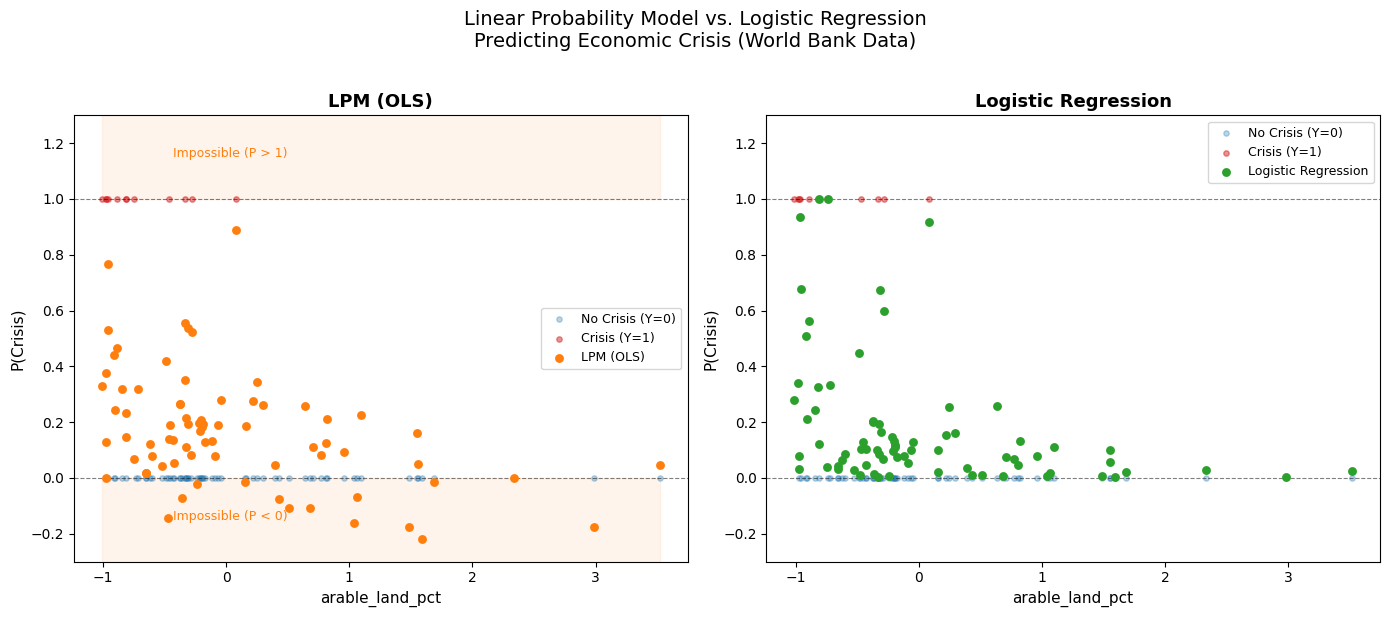

Figure saved as lpm_vs_logistic.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=False)

COLOR_CRISIS    = '#d62728'
COLOR_NO_CRISIS = '#1f77b4'
COLOR_LPM       = '#ff7f0e'
COLOR_LOGIT     = '#2ca02c'

x_vals = X_test_lpm[:, 0]
crisis_mask = y_binary_test == 1

for ax, model_preds, model_name, color in [
    (axes[0], lpm_preds,   'LPM (OLS)',           COLOR_LPM),
    (axes[1], logit_fitted, 'Logistic Regression', COLOR_LOGIT)
]:
    ax.scatter(x_vals[~crisis_mask], y_binary_test[~crisis_mask],
               color=COLOR_NO_CRISIS, alpha=0.3, s=15, label='No Crisis (Y=0)', zorder=2)
    ax.scatter(x_vals[crisis_mask], y_binary_test[crisis_mask],
               color=COLOR_CRISIS, alpha=0.5, s=15, label='Crisis (Y=1)', zorder=2)

    ax.scatter(x_vals, model_preds, color=color, lw=2.5, s=15,
               label=model_name, zorder=3)

    ax.axhline(0, color='black', lw=0.8, linestyle='--', alpha=0.5)
    ax.axhline(1, color='black', lw=0.8, linestyle='--', alpha=0.5)

    ax.set_xlabel(lasso_selected_names[0], fontsize=11)
    ax.set_ylabel('P(Crisis)', fontsize=11)
    ax.set_title(model_name, fontsize=13, fontweight='bold')
    ax.legend(fontsize=9)
    ax.set_ylim(-0.3, 1.3)

axes[0].fill_between(sorted(x_vals), -0.3, 0, color=COLOR_LPM, alpha=0.08)
axes[0].fill_between(sorted(x_vals),  1, 1.3, color=COLOR_LPM, alpha=0.08)
axes[0].text(x_vals.mean(), -0.15, 'Impossible (P < 0)', fontsize=9, color=COLOR_LPM, ha='center')
axes[0].text(x_vals.mean(),  1.15, 'Impossible (P > 1)', fontsize=9, color=COLOR_LPM, ha='center')

fig.suptitle('Linear Probability Model vs. Logistic Regression\nPredicting Economic Crisis (World Bank Data)',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('lpm_vs_logistic.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved as lpm_vs_logistic.png")

In [ ]:
naive_predictions = np.zeros(len(y_binary_test))

naive_accuracy = (naive_predictions == y_binary_test).mean()
naive_recall   = recall_score(y_binary_test, naive_predictions)

print(f"Naïve baseline accuracy:             {naive_accuracy:.4%}")
print(f"Naïve baseline recall (crisis class): {naive_recall:.4%}")
print(f"→ High accuracy, zero recall. The accuracy paradox in action.")

# Logistic regression at default threshold τ = 0.5
logit_predictions = logit_model.predict(X_test_lpm)

logit_accuracy = (logit_predictions == y_binary_test).mean()
logit_recall   = recall_score(y_binary_test, logit_predictions)

print(f"\nLogistic Regression (τ = 0.5):")
print(f"Accuracy:             {logit_accuracy:.4%}")
print(f"Recall (crisis class): {logit_recall:.4%}")

Naïve baseline accuracy:             84.2105%
Naïve baseline recall (crisis class): 0.0000%
→ High accuracy, zero recall. The accuracy paradox in action.

Logistic Regression (τ = 0.5):
Accuracy:             85.5263%
Recall (crisis class): 41.6667%


Written response (2–3 sentences): If you reported only accuracy to the Division Chief, would she be impressed or misled? Explain the accuracy paradox in the context of this specific dataset’s class distribution.
1. She would be misled because the crisis class is relatively rare, a model can achieve high accuracy by simply predicting no crisis for almost everyone.

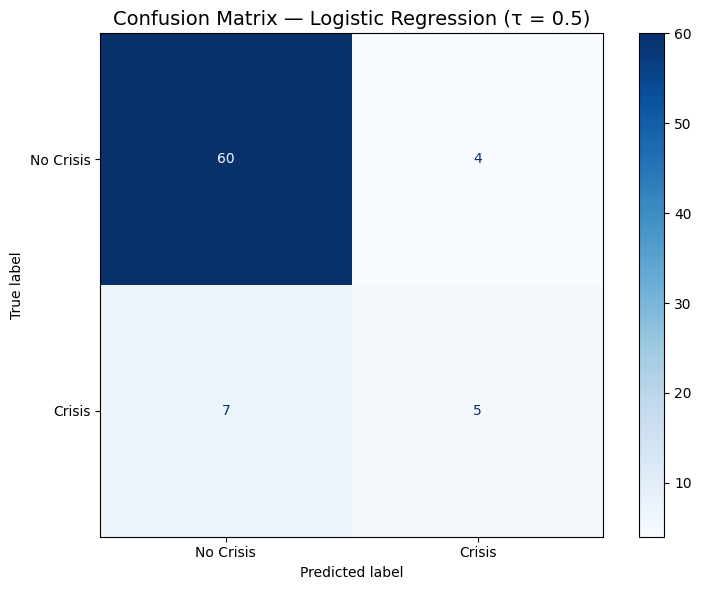

True Positives  (crises correctly flagged): 5
False Negatives (crises missed):            7
False Positives (false alarms):             4
True Negatives  (correctly clear):          60

Classification Report (τ = 0.5):
              precision    recall  f1-score   support

   No Crisis       0.90      0.94      0.92        64
      Crisis       0.56      0.42      0.48        12

    accuracy                           0.86        76
   macro avg       0.73      0.68      0.70        76
weighted avg       0.84      0.86      0.85        76


→ Focus on the CRISIS row. That's the class that matters.
→ 'macro avg' = unweighted mean across classes.
→ 'weighted avg' = weighted by class size (dominated by majority class — just like accuracy).


In [ ]:
cm = confusion_matrix(y_binary_test, logit_predictions)
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Crisis', 'Crisis'])
disp.plot(ax=ax, cmap='Blues', values_format=',')
ax.set_title('Confusion Matrix — Logistic Regression (τ = 0.5)', fontsize=14)
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Positives  (crises correctly flagged): {tp}")
print(f"False Negatives (crises missed):            {fn}")
print(f"False Positives (false alarms):             {fp}")
print(f"True Negatives  (correctly clear):          {tn}")

print("\nClassification Report (τ = 0.5):")
print("=" * 60)
print(classification_report(y_binary_test, logit_predictions, target_names=['No Crisis', 'Crisis']))
print("\n→ Focus on the CRISIS row. That's the class that matters.")
print("→ 'macro avg' = unweighted mean across classes.")
print("→ 'weighted avg' = weighted by class size (dominated by majority class — just like accuracy).")

Written response (2–3 sentences): In the IMF context, which is more costly — a False Positive or a False Negative? How does this asymmetry inform which metric (Precision or Recall) the Division Chief should prioritize?
1. A false negative is far more costly than a false positive, because you would then be missing a real crisis. A false alarm is still costly but, but is severly less costly than missing a real crisis


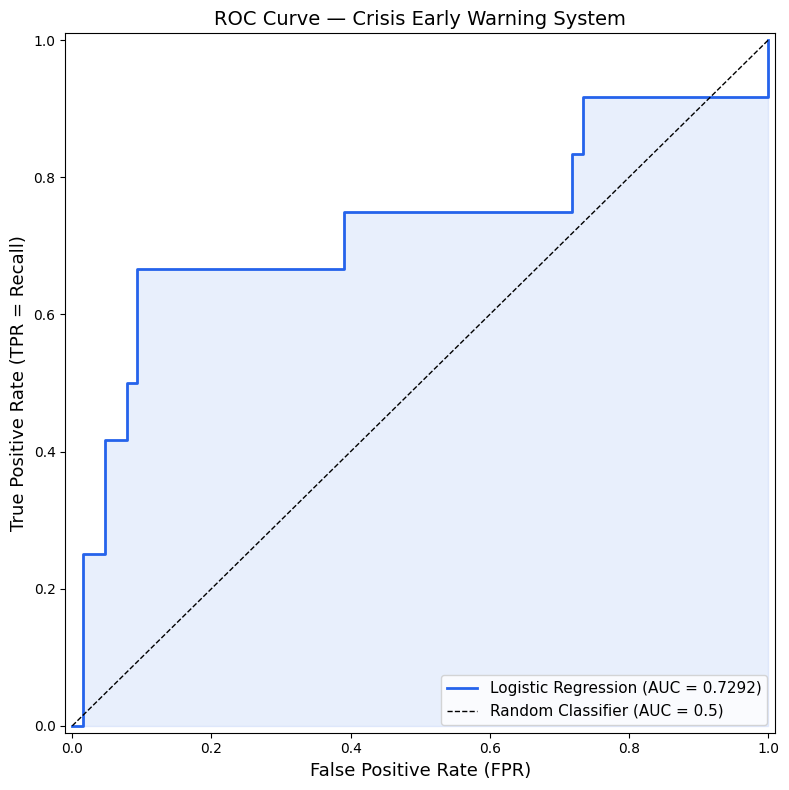

ROC-AUC = 0.7292


In [ ]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_binary_test, y_prob)
auc_score   = roc_auc_score(y_binary_test, y_prob)

fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(fpr, tpr, color='#2563eb', linewidth=2, label=f'Logistic Regression (AUC = {auc_score:.4f})')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier (AUC = 0.5)')
ax.fill_between(fpr, tpr, alpha=0.1, color='#2563eb')
ax.set_xlabel('False Positive Rate (FPR)', fontsize=13)
ax.set_ylabel('True Positive Rate (TPR = Recall)', fontsize=13)
ax.set_title('ROC Curve — Crisis Early Warning System', fontsize=14)
ax.legend(loc='lower right', fontsize=11)
ax.set_xlim([-0.01, 1.01])
ax.set_ylim([-0.01, 1.01])
plt.tight_layout()
plt.show()
print(f"ROC-AUC = {auc_score:.4f}")

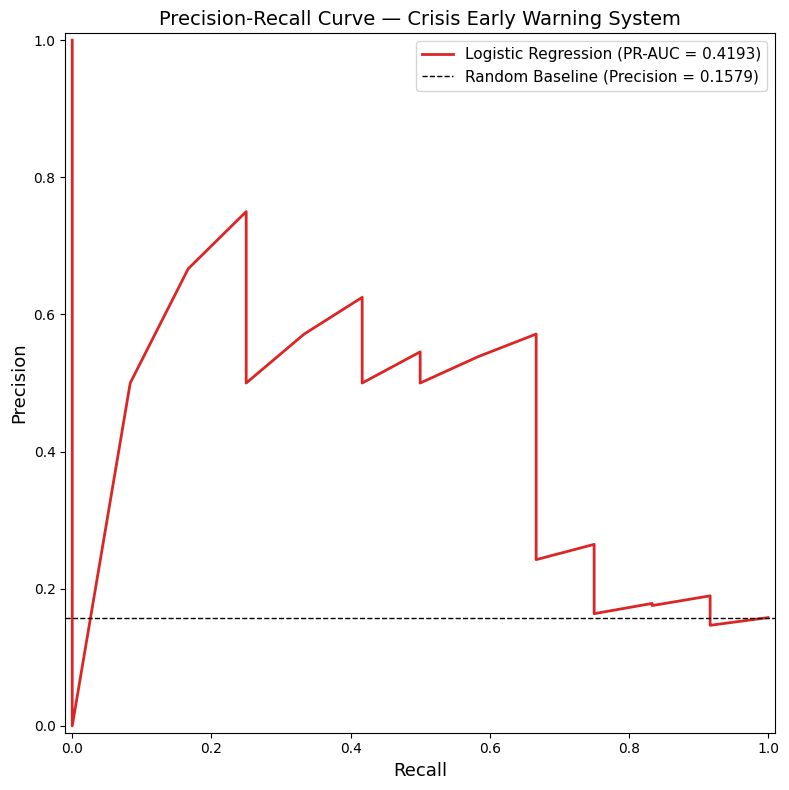

PR-AUC = 0.4193


In [ ]:
# Precision-Recall Curve
precision_vals, recall_vals, _ = precision_recall_curve(y_binary_test, y_prob)
pr_auc = auc(recall_vals, precision_vals)

fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(recall_vals, precision_vals, color='#dc2626', linewidth=2,
        label=f'Logistic Regression (PR-AUC = {pr_auc:.4f})')
baseline = y_binary_test.mean()
ax.axhline(y=baseline, color='k', linestyle='--', linewidth=1,
           label=f'Random Baseline (Precision = {baseline:.4f})')
ax.set_xlabel('Recall', fontsize=13)
ax.set_ylabel('Precision', fontsize=13)
ax.set_title('Precision-Recall Curve — Crisis Early Warning System', fontsize=14)
ax.legend(loc='upper right', fontsize=11)
ax.set_xlim([-0.01, 1.01])
ax.set_ylim([-0.01, 1.01])
plt.tight_layout()
plt.show()
print(f"PR-AUC = {pr_auc:.4f}")

Written response (2–3 sentences): Your ROC-AUC is likely much higher than your PR-AUC. Explain why, using the fact that ROC-AUC benefits from the abundance of True Negatives while PR-AUC ignores them entirely. Which curve is more informative for the IMF’s crisis detection mission?
1. Roc-auc is higher than pr-auc because the roc curve benefits from the large number of true negatives in the dataset. precision recall focuses more directly on performance for the positive class

CAPACITY-CONSTRAINED THRESHOLD
Threshold τ        : 0.68
Countries flagged  : 4
Precision          : 0.7500
Recall             : 0.2500
F1                 : 0.3750
F1-OPTIMAL THRESHOLD
Threshold τ        : 0.26
F1                 : 0.6154
Countries flagged  : 14


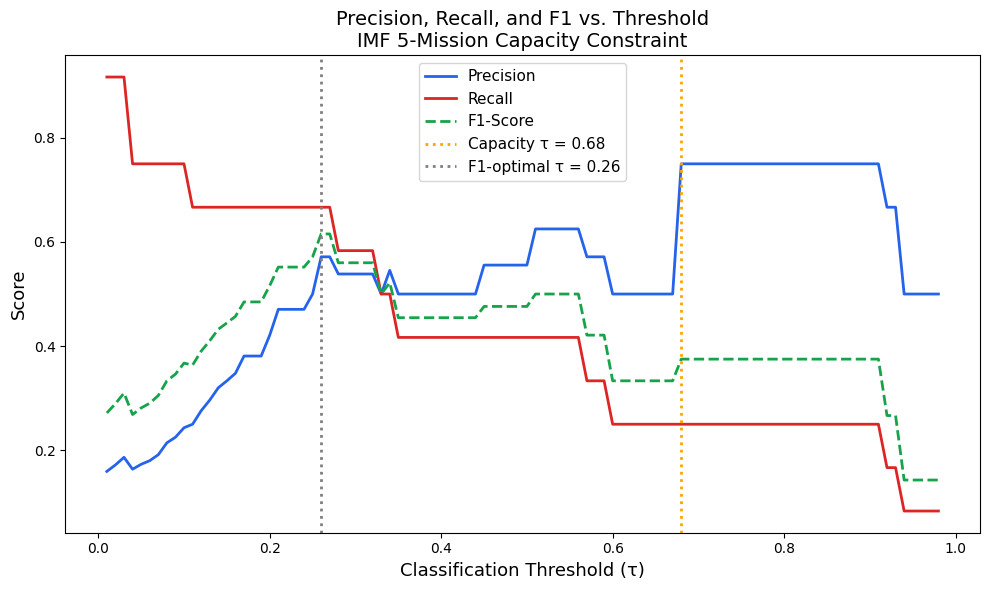


→ F1-optimal τ = 0.26 vs. capacity-constrained τ = 0.68
→ The capacity constraint forces a higher threshold, trading recall for precision.


In [ ]:
# ============================================================
# PHASE 2 — Step 3.4: Threshold Analysis — The 5-Mission Constraint
# ============================================================

threshold_range = np.arange(0.01, 0.99, 0.01)

f1_scores         = []
precision_scores  = []
recall_scores     = []
countries_flagged = []

for tau in threshold_range:
    y_pred_tau = (y_prob >= tau).astype(int)
    f1_scores.append(f1_score(y_binary_test, y_pred_tau, zero_division=0))
    precision_scores.append(precision_score(y_binary_test, y_pred_tau, zero_division=0))
    recall_scores.append(recall_score(y_binary_test, y_pred_tau, zero_division=0))
    countries_flagged.append(y_pred_tau.sum())

# Capacity-constrained threshold: lowest tau that flags at most 5 countries
capacity_mask = [n <= 5 for n in countries_flagged]
cap_idx  = next(i for i, valid in enumerate(capacity_mask) if valid)
cap_tau  = threshold_range[cap_idx]
cap_prec = precision_scores[cap_idx]
cap_rec  = recall_scores[cap_idx]
cap_f1   = f1_scores[cap_idx]
cap_flag = countries_flagged[cap_idx]

# F1-optimal threshold
best_idx  = np.argmax(f1_scores)
best_tau  = threshold_range[best_idx]
best_f1   = f1_scores[best_idx]

print("CAPACITY-CONSTRAINED THRESHOLD")
print(f"Threshold τ        : {cap_tau:.2f}")
print(f"Countries flagged  : {cap_flag}")
print(f"Precision          : {cap_prec:.4f}")
print(f"Recall             : {cap_rec:.4f}")
print(f"F1                 : {cap_f1:.4f}")

print("F1-OPTIMAL THRESHOLD")
print(f"Threshold τ        : {best_tau:.2f}")
print(f"F1                 : {best_f1:.4f}")
print(f"Countries flagged  : {countries_flagged[best_idx]}")

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(threshold_range, precision_scores, label='Precision', color='#2563eb', linewidth=2)
ax.plot(threshold_range, recall_scores,    label='Recall',    color='#dc2626', linewidth=2)
ax.plot(threshold_range, f1_scores,        label='F1-Score',  color='#16a34a', linewidth=2, linestyle='--')

ax.axvline(x=cap_tau,  color='orange', linestyle=':', linewidth=2, label=f'Capacity τ = {cap_tau:.2f}')
ax.axvline(x=best_tau, color='gray',   linestyle=':', linewidth=2, label=f'F1-optimal τ = {best_tau:.2f}')

ax.set_xlabel('Classification Threshold (τ)', fontsize=13)
ax.set_ylabel('Score', fontsize=13)
ax.set_title('Precision, Recall, and F1 vs. Threshold\nIMF 5-Mission Capacity Constraint', fontsize=14)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('threshold_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n→ F1-optimal τ = {best_tau:.2f} vs. capacity-constrained τ = {cap_tau:.2f}")
print(f"→ The capacity constraint forces a higher threshold, trading recall for precision.")

Written response (3–5 sentences): You are writing a one-paragraph memo to the Division Chief recommending which threshold the IMF should adopt. State your recommendation, the Recall it achieves, and what it means in operational terms (e.g., “Of the X crisis countries in the test set, we would catch Y and miss Z”). Acknowledge the tradeoff explicitly.

1. I recommend that the IMF adopt the capacity contrained threshold of 0.68 than the f1 optimal threshold of 0.26. This would be a stricter rule, so it would improve the precision of the model.


Prime Prompt:
Using my existing training data objects X_train_scaled, y_train, and feature_names in Google Colab, write a single clean Python script that draws 200 bootstrap resamples (with replacement) from the training data.
Fits LassoCV on each resample and records the selected features.
Computes the selection frequency for each predictor: the fraction of bootstrap samples in which Lasso assigns it a non-zero coefficient.
Produces a horizontal bar chart ranking predictors by selection frequency, with a vertical reference line at 50%.

                         Predictor  Selection_Frequency
3              fdi_inflows_pct_gdp                0.110
9                    inflation_cpi                0.085
30                urbanization_pct                0.085
31                 tariff_rate_avg                0.085
24   education_expenditure_pct_gdp                0.080
20          exchange_rate_official                0.080
29               population_growth                0.080
2               royalties_receipts                0.075
27               unemployment_rate                0.075
14                      trade_cpia                0.070
10              real_interest_rate                0.070
0                  arable_land_pct                0.070
15     mobile_subscriptions_per100                0.060
19  natural_resource_rents_pct_gdp                0.060
13            property_rights_cpia                0.055


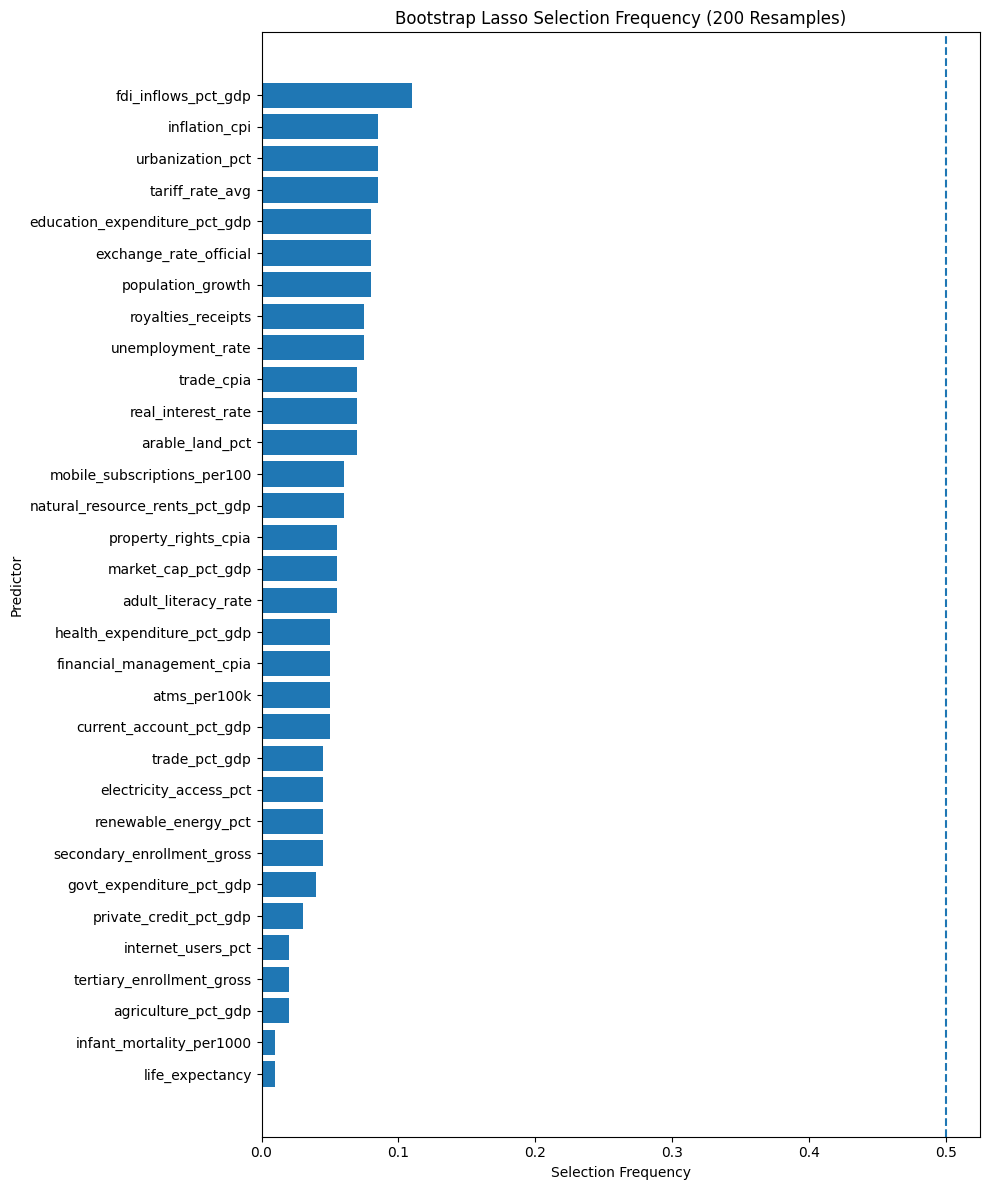

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LassoCV
from sklearn.utils import resample

# Ensure X_train_scaled is a DataFrame so feature names are preserved
if isinstance(X_train_scaled, pd.DataFrame):
    X_boot_base = X_train_scaled.copy()
else:
    X_boot_base = pd.DataFrame(X_train_scaled, columns=feature_names)

n_bootstrap = 200
n_features = X_boot_base.shape[1]
selection_counts = np.zeros(n_features)

for b in range(n_bootstrap):
    X_resampled = resample(
        X_boot_base,
        replace=True,
        n_samples=len(X_boot_base),
        random_state=42 + b
    )

    lasso_boot = LassoCV(cv=5, random_state=42, max_iter=10000)
    lasso_boot.fit(X_resampled, y_train)

    selected = (lasso_boot.coef_ != 0)
    selection_counts += selected.astype(int)

selection_freq = selection_counts / n_bootstrap

selection_df = pd.DataFrame({
    "Predictor": X_boot_base.columns,
    "Selection_Frequency": selection_freq
}).sort_values("Selection_Frequency", ascending=False)

print(selection_df.head(15).round(3))

plt.figure(figsize=(10, 12))
plt.barh(selection_df["Predictor"], selection_df["Selection_Frequency"])
plt.axvline(0.50, linestyle="--")
plt.xlabel("Selection Frequency")
plt.ylabel("Predictor")
plt.title("Bootstrap Lasso Selection Frequency (200 Resamples)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Stable predictors were fdi_inflows_pct_gdp, inflation_cpi, urbanization_pct, tariff_rate_avg, while there were no fragile predictors.

Prime Prompt: Write a python script that Sweeps thresholds from 0.01 to 0.99. At each threshold, computes the total expected cost: FN × $50B + FP × $2M. Plots the expected cost curve as a function of τ. Identifies and annotates the cost-minimizing threshold.

Cost-minimizing threshold: 0.03
Minimum expected cost: $50,096,000,000
False Positives at optimal threshold: 48
False Negatives at optimal threshold: 1


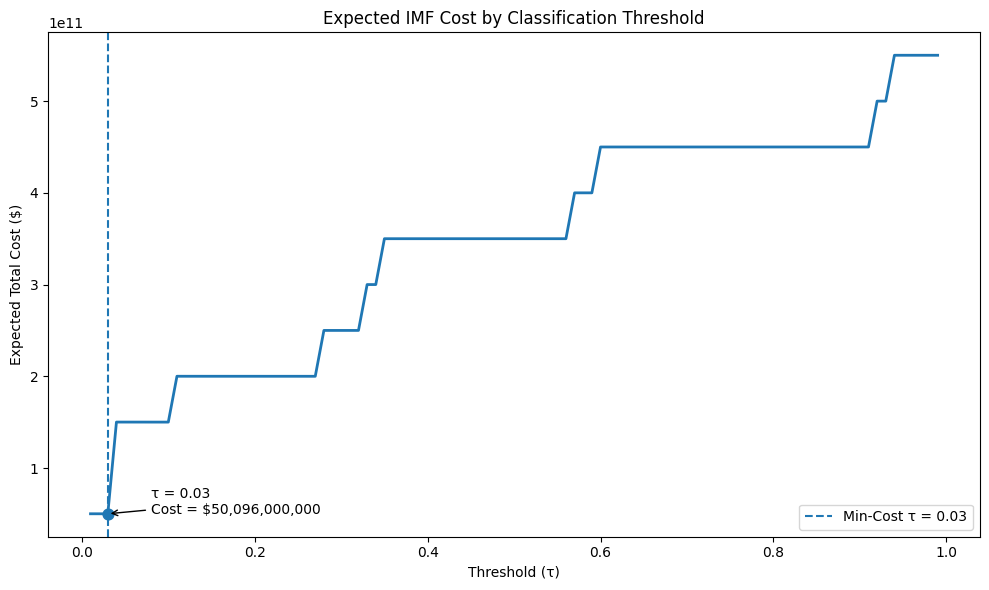

,Threshold,False_Positives,False_Negatives,Total_Cost
0,0.01,58,1,50116000000
1,0.02,53,1,50106000000
2,0.03,48,1,50096000000
3,0.04,46,3,150092000000
4,0.05,43,3,150086000000


In [104]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Sweep thresholds
thresholds = np.arange(0.01, 1.00, 0.01)

results = []

for tau in thresholds:
    y_pred_tau = (y_prob >= tau).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_binary_test, y_pred_tau).ravel()

    total_cost = fn * 50_000_000_000 + fp * 2_000_000

    results.append({
        "Threshold": tau,
        "False_Positives": fp,
        "False_Negatives": fn,
        "Total_Cost": total_cost
    })

cost_df = pd.DataFrame(results)

# Find cost-minimizing threshold
best_idx = cost_df["Total_Cost"].idxmin()
best_tau = cost_df.loc[best_idx, "Threshold"]
best_cost = cost_df.loc[best_idx, "Total_Cost"]
best_fp = cost_df.loc[best_idx, "False_Positives"]
best_fn = cost_df.loc[best_idx, "False_Negatives"]

print(f"Cost-minimizing threshold: {best_tau:.2f}")
print(f"Minimum expected cost: ${best_cost:,.0f}")
print(f"False Positives at optimal threshold: {best_fp}")
print(f"False Negatives at optimal threshold: {best_fn}")

# Plot expected cost curve
plt.figure(figsize=(10, 6))
plt.plot(cost_df["Threshold"], cost_df["Total_Cost"], linewidth=2)
plt.axvline(best_tau, linestyle="--", linewidth=1.5, label=f"Min-Cost τ = {best_tau:.2f}")
plt.scatter(best_tau, best_cost, s=60)

plt.annotate(
    f"τ = {best_tau:.2f}\nCost = ${best_cost:,.0f}",
    xy=(best_tau, best_cost),
    xytext=(best_tau + 0.05, best_cost),
    arrowprops=dict(arrowstyle="->")
)

plt.xlabel("Threshold (τ)")
plt.ylabel("Expected Total Cost ($)")
plt.title("Expected IMF Cost by Classification Threshold")
plt.legend()
plt.tight_layout()
plt.show()

cost_df.head()